<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v2/blob/master/Student_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10 · Student Comparison — 2×2 Controlled Design

Loads best checkpoints from all four student notebooks (06–09) and produces
a controlled comparison that isolates architecture and initialization effects separately.

## Experimental design

| | Scratch | Pretrained |
|---|---|---|
| **MobileNetV2** | notebook 06 | notebook 07 |
| **MobileNetV3** | notebook 08 | notebook 09 |

**Two independent claims:**

**Claim 1 — Architecture effect** (initialization held constant):
- *Both scratch:* V2 scratch (nb 06) vs V3 scratch (nb 08)
- *Both pretrained:* V2 pretrained (nb 07) vs V3 pretrained (nb 09)
- If V3 consistently wins → architecture improvement is real, independent of initialization

**Claim 2 — Initialization effect** (architecture held constant):
- *V2 family:* V2 scratch (nb 06) vs V2 pretrained (nb 07)
- *V3 family:* V3 scratch (nb 08) vs V3 pretrained (nb 09)
- If pretrained consistently wins → ImageNet initialization helps even for binary classification on small datasets

**Selected student for KD:** MobileNetV3-Small pretrained (notebook 09).
Justified by winning on both dimensions — confirmed below.

⚠️  Update checkpoint paths after running notebooks 06–09.


In [1]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place the utils/ folder at: My Drive/thesis/utils/")


Mounted at /content/drive
✅ utils loaded from Drive


In [2]:
# ── Standard imports ────────────────────────────────────────────────
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from utils.dataset import prepare_dataset, get_loaders
from utils.models  import (
    MobileNetV2_Scratch, MobileNetV2_Pretrained,
    MobileNetV3_Scratch, MobileNetV3_Pretrained,
    count_params, model_size_mb, STUDENT_REGISTRY,
)
from utils.train import (
    setup_device, set_seed, evaluate,
    train_multi_seed, plot_history,
)

device = setup_device(seed=41)


Device: cpu


In [3]:
# ── Dataset setup ───────────────────────────────────────────────────
prepare_dataset()


1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests


PosixPath('/content/vww_work/extracted/vw_coco2014_96')

In [4]:
SAVE_DIR = "/content/drive/My Drive/Colab Notebooks"


In [8]:
# ── Checkpoint configuration ────────────────────────────────────────
# Replace seed_XX with your best seed number from each notebook

STUDENT_CKPTS = {
    "MobileNetV2 (scratch)":         (MobileNetV2_Scratch,    f"{SAVE_DIR}/mobilenetv2_baseline_seed_41.pth"),
    "MobileNetV2 (pretrained)":      (MobileNetV2_Pretrained, f"{SAVE_DIR}/mobilenetv2_pretrained_seed_52.pth"),
    "MobileNetV3-Small (scratch)":   (MobileNetV3_Scratch,    f"{SAVE_DIR}/mobilenetv3_scratch_seed_41.pth"),
    "MobileNetV3-Small (pretrained)":(MobileNetV3_Pretrained, f"{SAVE_DIR}/mobilenetv3_baseline_seed_63.pth"),
}


In [9]:
# ── Load all models and measure metrics ─────────────────────────────
_, val_loader = get_loaders(batch_size=64)

def measure_latency(model, device, runs=200, warmup=20):
    model.eval()
    dummy = torch.randn(1, 3, 96, 96, device=device)
    with torch.no_grad():
        for _ in range(warmup): model(dummy)
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(runs): model(dummy)
        if device.type == "cuda": torch.cuda.synchronize()
    return (time.time() - t0) / runs * 1000   # ms

rows = []
loaded = {}   # keep models in memory for later

for name, (fn, ckpt) in STUDENT_CKPTS.items():
    if not os.path.exists(ckpt):
        print(f"⚠️  Skipping {name} — checkpoint not found: {ckpt}")
        continue
    m = fn().to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()
    loaded[name] = m

    acc  = evaluate(m, val_loader, device)
    tp,_ = count_params(m)
    size = model_size_mb(m)
    lat  = measure_latency(m, device)

    rows.append({
        "Model":          name,
        "Architecture":   "MobileNetV2" if "V2" in name else "MobileNetV3-Small",
        "Init":           "Scratch" if "scratch" in name else "Pretrained",
        "Val Acc (%)":    round(acc*100, 2),
        "Params (M)":     round(tp/1e6, 2),
        "Size (MB)":      round(size, 2),
        "Latency (ms)":   round(lat, 3),
    })
    print(f"{name:42s}  acc={acc*100:.2f}%  params={tp/1e6:.2f}M  "
          f"size={size:.2f}MB  lat={lat:.3f}ms")


Train: 7000 | Val: 1500 | Batch: 64


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


MobileNetV2 (scratch)                       acc=78.80%  params=0.15M  size=0.68MB  lat=8.823ms
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 108MB/s] 


MobileNetV2 (pretrained)                    acc=76.73%  params=2.23M  size=9.15MB  lat=12.991ms
MobileNetV3-Small (scratch)                 acc=77.53%  params=1.52M  size=6.21MB  lat=9.064ms
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 39.0MB/s]


MobileNetV3-Small (pretrained)              acc=77.40%  params=1.52M  size=6.21MB  lat=7.782ms


In [10]:
# ── Full comparison table ────────────────────────────────────────────
import pandas as pd

df = pd.DataFrame(rows).set_index("Model")
print("\n" + "="*70)
print("Student Comparison — Full Results")
print("="*70)
print(df.to_string())



Student Comparison — Full Results
                                     Architecture        Init  Val Acc (%)  Params (M)  Size (MB)  Latency (ms)
Model                                                                                                          
MobileNetV2 (scratch)                 MobileNetV2     Scratch        78.80        0.15       0.68         8.823
MobileNetV2 (pretrained)              MobileNetV2  Pretrained        76.73        2.23       9.15        12.991
MobileNetV3-Small (scratch)     MobileNetV3-Small     Scratch        77.53        1.52       6.21         9.064
MobileNetV3-Small (pretrained)  MobileNetV3-Small  Pretrained        77.40        1.52       6.21         7.782


In [11]:
# ── Claim 1: Architecture effect ────────────────────────────────────
print("\n" + "="*70)
print("Claim 1 — Architecture Effect (V2 vs V3)")
print("="*70)

df_arch = df.pivot_table(values="Val Acc (%)", index="Architecture", columns="Init")
print(df_arch.to_string())

if "Scratch" in df_arch.columns and "MobileNetV2" in df_arch.index and "MobileNetV3-Small" in df_arch.index:
    scratch_delta = df_arch.loc["MobileNetV3-Small", "Scratch"] - df_arch.loc["MobileNetV2", "Scratch"]
    print(f"\n  V3 vs V2 (both scratch):    {scratch_delta:+.2f}%")

if "Pretrained" in df_arch.columns and "MobileNetV2" in df_arch.index and "MobileNetV3-Small" in df_arch.index:
    pt_delta = df_arch.loc["MobileNetV3-Small", "Pretrained"] - df_arch.loc["MobileNetV2", "Pretrained"]
    print(f"  V3 vs V2 (both pretrained): {pt_delta:+.2f}%")
    if scratch_delta > 0 and pt_delta > 0:
        print("  ✅ V3 architecture outperforms V2 under both initialization conditions.")
    else:
        print("  ⚠️  Mixed result — architecture effect is inconsistent.")



Claim 1 — Architecture Effect (V2 vs V3)
Init               Pretrained  Scratch
Architecture                          
MobileNetV2             76.73    78.80
MobileNetV3-Small       77.40    77.53

  V3 vs V2 (both scratch):    -1.27%
  V3 vs V2 (both pretrained): +0.67%
  ⚠️  Mixed result — architecture effect is inconsistent.


In [12]:
# ── Claim 2: Initialization effect ──────────────────────────────────
print("\n" + "="*70)
print("Claim 2 — Initialization Effect (Scratch vs Pretrained)")
print("="*70)

df_init = df.pivot_table(values="Val Acc (%)", index="Init", columns="Architecture")
print(df_init.to_string())

if "MobileNetV2" in df_init.columns and "Scratch" in df_init.index and "Pretrained" in df_init.index:
    v2_delta = df_init.loc["Pretrained", "MobileNetV2"] - df_init.loc["Scratch", "MobileNetV2"]
    print(f"\n  Pretrained vs Scratch (V2 arch): {v2_delta:+.2f}%")

if "MobileNetV3-Small" in df_init.columns and "Scratch" in df_init.index and "Pretrained" in df_init.index:
    v3_delta = df_init.loc["Pretrained", "MobileNetV3-Small"] - df_init.loc["Scratch", "MobileNetV3-Small"]
    print(f"  Pretrained vs Scratch (V3 arch): {v3_delta:+.2f}%")
    if v2_delta > 0 and v3_delta > 0:
        print("  ✅ Pretrained initialization outperforms scratch under both architectures.")
    else:
        print("  ⚠️  Mixed result — initialization effect is inconsistent.")



Claim 2 — Initialization Effect (Scratch vs Pretrained)
Architecture  MobileNetV2  MobileNetV3-Small
Init                                        
Pretrained          76.73              77.40
Scratch             78.80              77.53

  Pretrained vs Scratch (V2 arch): -2.07%
  Pretrained vs Scratch (V3 arch): -0.13%
  ⚠️  Mixed result — initialization effect is inconsistent.


In [13]:
# ── Winner selection ─────────────────────────────────────────────────
print("\n" + "="*70)
print("Selected Student for Knowledge Distillation")
print("="*70)

winner = df["Val Acc (%)"].idxmax()
w = df.loc[winner]
print(f"  Model      : {winner}")
print(f"  Val Acc    : {w['Val Acc (%)']:.2f}%")
print(f"  Params     : {w['Params (M)']:.2f}M")
print(f"  Size       : {w['Size (MB)']:.2f}MB")
print(f"  Latency    : {w['Latency (ms)']:.3f}ms")
print(f"\n  → Set STUDENT_MODEL_FN = MobileNetV3_Pretrained in notebooks 11 and 12")
print(f"    Set STUDENT_CKPT to the best checkpoint from notebook 09")



Selected Student for Knowledge Distillation
  Model      : MobileNetV2 (scratch)
  Val Acc    : 78.80%
  Params     : 0.15M
  Size       : 0.68MB
  Latency    : 8.823ms

  → Set STUDENT_MODEL_FN = MobileNetV3_Pretrained in notebooks 11 and 12
    Set STUDENT_CKPT to the best checkpoint from notebook 09


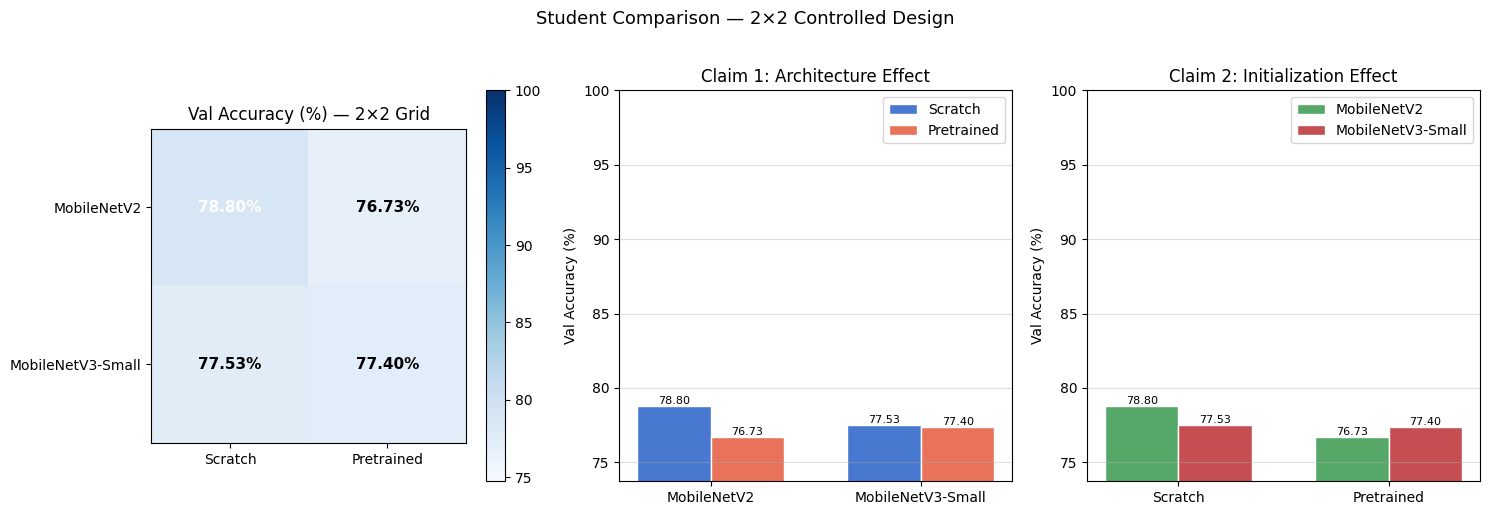

In [14]:
# ── Visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Plot 1: 2×2 accuracy heatmap ──────────────────────────────────
ax = axes[0]
if len(df) == 4:
    import numpy as np
    archs = ["MobileNetV2", "MobileNetV3-Small"]
    inits = ["Scratch", "Pretrained"]
    heat  = np.array([
        [df.loc["MobileNetV2 (scratch)",         "Val Acc (%)"],
         df.loc["MobileNetV2 (pretrained)",       "Val Acc (%)"]],
        [df.loc["MobileNetV3-Small (scratch)",    "Val Acc (%)"],
         df.loc["MobileNetV3-Small (pretrained)", "Val Acc (%)"]],
    ])
    im = ax.imshow(heat, cmap="Blues", vmin=heat.min()-2, vmax=100)
    ax.set_xticks([0,1]); ax.set_xticklabels(inits)
    ax.set_yticks([0,1]); ax.set_yticklabels(archs)
    ax.set_title("Val Accuracy (%) — 2×2 Grid")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{heat[i,j]:.2f}%", ha="center", va="center",
                    color="white" if heat[i,j] > (heat.max()+heat.min())/2 else "black",
                    fontsize=11, fontweight="bold")
    plt.colorbar(im, ax=ax)

# ── Plot 2: Architecture effect bar chart ─────────────────────────
ax = axes[1]
x      = [0, 1]
width  = 0.35
keys_scratch   = ["MobileNetV2 (scratch)",   "MobileNetV3-Small (scratch)"]
keys_pretrained= ["MobileNetV2 (pretrained)","MobileNetV3-Small (pretrained)"]
scratch_accs   = [df.loc[k, "Val Acc (%)"] if k in df.index else 0 for k in keys_scratch]
pt_accs        = [df.loc[k, "Val Acc (%)"] if k in df.index else 0 for k in keys_pretrained]
bars1 = ax.bar([i - width/2 for i in x], scratch_accs,   width, label="Scratch",    color="#4878D0", edgecolor="white")
bars2 = ax.bar([i + width/2 for i in x], pt_accs,        width, label="Pretrained", color="#E8735A", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(["MobileNetV2", "MobileNetV3-Small"])
ax.set_ylabel("Val Accuracy (%)"); ax.set_title("Claim 1: Architecture Effect")
ax.set_ylim(min(scratch_accs + pt_accs) - 3, 100)
ax.legend(); ax.grid(axis="y", alpha=0.4)
for bar in list(bars1) + list(bars2):
    ax.annotate(f"{bar.get_height():.2f}",
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=8)

# ── Plot 3: Initialization effect bar chart ───────────────────────
ax = axes[2]
x     = [0, 1]
keys_v2 = ["MobileNetV2 (scratch)",       "MobileNetV2 (pretrained)"]
keys_v3 = ["MobileNetV3-Small (scratch)", "MobileNetV3-Small (pretrained)"]
v2_accs = [df.loc[k, "Val Acc (%)"] if k in df.index else 0 for k in keys_v2]
v3_accs = [df.loc[k, "Val Acc (%)"] if k in df.index else 0 for k in keys_v3]
bars3 = ax.bar([i - width/2 for i in x], v2_accs, width, label="MobileNetV2",       color="#55A868", edgecolor="white")
bars4 = ax.bar([i + width/2 for i in x], v3_accs, width, label="MobileNetV3-Small", color="#C44E52", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(["Scratch", "Pretrained"])
ax.set_ylabel("Val Accuracy (%)"); ax.set_title("Claim 2: Initialization Effect")
ax.set_ylim(min(v2_accs + v3_accs) - 3, 100)
ax.legend(); ax.grid(axis="y", alpha=0.4)
for bar in list(bars3) + list(bars4):
    ax.annotate(f"{bar.get_height():.2f}",
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=8)

plt.suptitle("Student Comparison — 2×2 Controlled Design", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
